In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
class DataManager:

    def __init__(self, url):
        self._data = pd.read_csv(url)

    def check_health(self):
        return self._data.isnull().sum()

In [ ]:
class TitanicAnalyzer(DataManager):

    def clean_data(self):

        # Fill missing Age values
        self._data["Age"] = self._data["Age"].fillna(
            self._data["Age"].median()
        )

        # Fill missing Embarked values
        self._data["Embarked"] = self._data["Embarked"].fillna(
            self._data["Embarked"].mode()[0]
        )

        # Drop Cabin column
        self._data.drop(columns=["Cabin"], inplace=True)

    def passenger_summary(self):

        print("\nPASSENGER SUMMARY")
        print("-" * 40)

        print(f"Total Passengers: {len(self._data)}")
        print(f"Total Survivors: {self._data['Survived'].sum()}")
        print(f"Survival Rate: {self._data['Survived'].mean() * 100:.2f}%")
        print(f"Average Age: {self._data['Age'].mean():.2f}")
        print(f"Highest Fare: {self._data['Fare'].max():.2f}")

    def get_survival_stats(self):

        stats = (
            self._data
            .groupby(["Pclass", "Sex"])["Survived"]
            .mean()
            * 100
        )

        return stats

    # DSA Logic (No Pandas mean())
    def identify_outliers(self):

        fares = list(self._data["Fare"])

        total = 0

        for fare in fares:
            total += fare

        mean = total / len(fares)

        outliers = []

        for index, fare in enumerate(fares):

            if fare > 3 * mean:
                outliers.append(index)

        return outliers

    # Polymorphism
    def visualize(self, plot_type):

        if plot_type == "survival":

            counts = self._data["Survived"].value_counts()

            plt.figure(figsize=(6, 4))

            plt.bar(
                ["Not Survived", "Survived"],
                counts.values
            )

            plt.title("Survival Distribution")
            plt.xlabel("Status")
            plt.ylabel("Number of Passengers")

            plt.show()

        elif plot_type == "age":

            plt.figure(figsize=(8, 5))

            plt.hist(
                self._data["Age"].dropna(),
                bins=10
            )

            plt.title("Age Distribution")
            plt.xlabel("Age")
            plt.ylabel("Number of Passengers")

            plt.show()

        else:
            print("Invalid plot type")

MISSING VALUES BEFORE CLEANING
----------------------------------------
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

MISSING VALUES AFTER CLEANING
----------------------------------------
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

PASSENGER SUMMARY
----------------------------------------
Total Passengers: 891
Total Survivors: 342
Survival Rate: 38.38%
Average Age: 29.36
Highest Fare: 512.33

SURVIVAL STATISTICS
----------------------------------------
Pclass  Sex   
1       female    96.808511
        male      36.885246
2       female    92.105263
        male      15.740741
3       female    50.000000
        male      13.544669
Name:

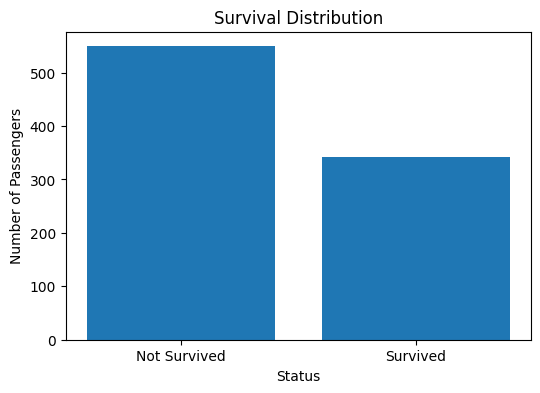

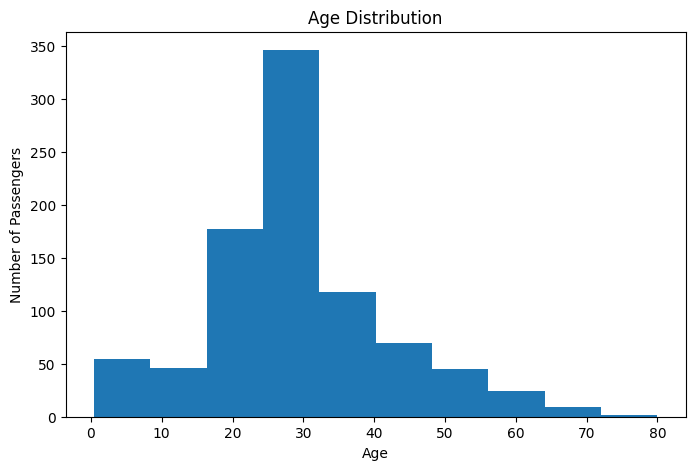

In [ ]:
URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

analyzer = TitanicAnalyzer(URL)

print("MISSING VALUES BEFORE CLEANING")
print("-" * 40)
print(analyzer.check_health())

# Clean Data
analyzer.clean_data()

print("\nMISSING VALUES AFTER CLEANING")
print("-" * 40)
print(analyzer.check_health())

# Passenger Summary
analyzer.passenger_summary()

# Survival Statistics
print("\nSURVIVAL STATISTICS")
print("-" * 40)
print(analyzer.get_survival_stats())

# Outlier Detection
outliers = analyzer.identify_outliers()

print("\nOUTLIER INDICES")
print("-" * 40)
print(outliers)

print(f"\nTotal Outliers Found: {len(outliers)}")

# Visualizations
analyzer.visualize("survival")
analyzer.visualize("age")